# STEP 1: INSTALASI LIBRARY

In [ ]:
!pip install krippendorff

import pandas as pd
import numpy as np
import krippendorff
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diinstall dan diimport\n")

✅ Library berhasil diinstall dan diimport



# STEP 2: LOAD DATA

In [ ]:
print("="*80)
print("STEP 2: LOAD DATA HASIL PELABELAN")
print("="*80 + "\n")

# ============================================================================
# 2.1: LOAD DATA ASPEK DETECTION (0 = tidak ada, 1 = ada)
# ============================================================================

print("2.1: LOAD DATA ASPEK DETECTION")
print("-"*80 + "\n")

path_lda_aspek = "/content/drive/MyDrive/SKRIPSI/DATASET/ulasan_plnmobile_labeling_aspek_LDA.csv"
path_ber_aspek = "/content/drive/MyDrive/SKRIPSI/DATASET/ulasan_plnmobile_labeling_aspek_BERTopic.csv"

df_lda_aspek = pd.read_csv(path_lda_aspek, sep=";", engine="python")
df_ber_aspek = pd.read_csv(path_ber_aspek, sep=";", engine="python")

print(f"✅ LDA Aspek: {len(df_lda_aspek)} ulasan")
print(f"   Columns: {df_lda_aspek.columns.tolist()}")
print(f"\n✅ BERTopic Aspek: {len(df_ber_aspek)} ulasan")
print(f"   Columns: {df_ber_aspek.columns.tolist()}")

print("\nSample Data LDA Aspek:")
print(df_lda_aspek.head(3))

# ============================================================================
# 2.2: LOAD DATA SENTIMEN CLASSIFICATION (0 = tidak ada, 1 = positif, 2 = negatif)
# ============================================================================

print("\n2.2: LOAD DATA SENTIMEN CLASSIFICATION")
print("-"*80 + "\n")

path_lda_sentimen = "/content/drive/MyDrive/SKRIPSI/DATASET/ulasan_plnmobile_labeling_LDA.csv"
path_ber_sentimen = "/content/drive/MyDrive/SKRIPSI/DATASET/ulasan_plnmobile_labeling_BERTopic.csv"

df_lda_sentimen = pd.read_csv(path_lda_sentimen, sep=";", engine="python")
df_ber_sentimen = pd.read_csv(path_ber_sentimen, sep=";", engine="python")

print(f"✅ LDA Sentimen: {len(df_lda_sentimen)} ulasan")
print(f"   Columns: {df_lda_sentimen.columns.tolist()}")
print(f"\n✅ BERTopic Sentimen: {len(df_ber_sentimen)} ulasan")
print(f"   Columns: {df_ber_sentimen.columns.tolist()}")

print("\nSample Data LDA Sentimen:")
print(df_lda_sentimen.head(3))

STEP 2: LOAD DATA HASIL PELABELAN

2.1: LOAD DATA ASPEK DETECTION
--------------------------------------------------------------------------------

✅ LDA Aspek: 16220 ulasan
   Columns: ['id', 'ulasan', 'final_text', 'Annotator1_User_Experience', 'Annotator1_Service_Quality', 'Annotator2_User_Experience', 'Annotator2_Service_Quality', 'Annotator3_User_Experience', 'Annotator3_Service_Quality']

✅ BERTopic Aspek: 16220 ulasan
   Columns: ['id', 'ulasan', 'final_text', 'Annotator1_User_Experience', 'Annotator1_Service_Quality', 'Annotator1_System_Reliability', 'Annotator2_User_Experience', 'Annotator2_Service_Quality', 'Annotator2_System_Reliability', 'Annotator3_User_Experience', 'Annotator3_Service_Quality', 'Annotator3_System_Reliability']

Sample Data LDA Aspek:
   id                                             ulasan  \
0   1  aplikasi yg sangat bermanfaat utk urusan kelis...   
1   2                   sangat membantu proses pengaduan   
2   3                      Lebih mudah dan ce

# STEP 3: CLEAN DATA

In [ ]:
print("\n" + "="*80)
print("STEP 3: CLEAN DATA")
print("="*80 + "\n")

# Kolom annotator untuk LDA
annotator_cols_lda_aspek = [
    "Annotator1_User_Experience",
    "Annotator1_Service_Quality",
    "Annotator2_User_Experience",
    "Annotator2_Service_Quality",
    "Annotator3_User_Experience",
    "Annotator3_Service_Quality"
]

annotator_cols_lda_sentimen = annotator_cols_lda_aspek.copy()

# Kolom annotator untuk BERTopic (3 aspek)
annotator_cols_ber_aspek = [
    "Annotator1_User_Experience",
    "Annotator1_Service_Quality",
    "Annotator1_System_Reliability",
    "Annotator2_User_Experience",
    "Annotator2_Service_Quality",
    "Annotator2_System_Reliability",
    "Annotator3_User_Experience",
    "Annotator3_Service_Quality",
    "Annotator3_System_Reliability"
]

annotator_cols_ber_sentimen = annotator_cols_ber_aspek.copy()

# Bersihkan data aspek
df_lda_aspek[annotator_cols_lda_aspek] = (
    df_lda_aspek[annotator_cols_lda_aspek]
    .replace(r'^\s*$', np.nan, regex=True)
    .apply(pd.to_numeric, errors='coerce')
)

df_ber_aspek[annotator_cols_ber_aspek] = (
    df_ber_aspek[annotator_cols_ber_aspek]
    .replace(r'^\s*$', np.nan, regex=True)
    .apply(pd.to_numeric, errors='coerce')
)

# Bersihkan data sentimen
df_lda_sentimen[annotator_cols_lda_sentimen] = (
    df_lda_sentimen[annotator_cols_lda_sentimen]
    .replace(r'^\s*$', np.nan, regex=True)
    .apply(pd.to_numeric, errors='coerce')
)

df_ber_sentimen[annotator_cols_ber_sentimen] = (
    df_ber_sentimen[annotator_cols_ber_sentimen]
    .replace(r'^\s*$', np.nan, regex=True)
    .apply(pd.to_numeric, errors='coerce')
)

print("✅ Data berhasil dibersihkan")


STEP 3: CLEAN DATA

✅ Data berhasil dibersihkan


# STEP 4: FUNGSI HELPER

In [ ]:
print("\n" + "="*80)
print("STEP 4: FUNGSI HELPER")
print("="*80 + "\n")

def prepare_reliability_matrix_aspek(df, aspect_name, annotators=['Annotator1', 'Annotator2', 'Annotator3']):
    """
    Siapkan reliability matrix untuk ASPECT DETECTION (0/1)

    Returns:
    --------
    numpy array shape (n_annotators, n_documents)
    Values: 0 = tidak ada aspek, 1 = ada aspek
    """
    reliability_data = []

    for annotator in annotators:
        col_name = f"{annotator}_{aspect_name.replace(' ', '_')}"

        if col_name in df.columns:
            # Data aspek: 0 = tidak ada, 1 = ada
            ratings = df[col_name].values
            reliability_data.append(ratings)
        else:
            raise ValueError(f"Kolom {col_name} tidak ditemukan!")

    return np.array(reliability_data, dtype=float)


def prepare_reliability_matrix_sentimen(df, aspect_name, annotators=['Annotator1', 'Annotator2', 'Annotator3']):
    """
    Siapkan reliability matrix untuk SENTIMENT CLASSIFICATION (1/2)

    PENTING: Hanya untuk dokumen yang SEMUA annotator sepakat ada aspek (=1)

    Returns:
    --------
    numpy array shape (n_annotators, n_documents)
    Values: 1 = Positive, 2 = Negative, np.nan = skip (tidak ada aspek)
    """
    reliability_data = []

    # Ambil data dari semua annotator
    annotator_data = []
    for annotator in annotators:
        col_name = f"{annotator}_{aspect_name.replace(' ', '_')}"

        if col_name in df.columns:
            annotator_data.append(df[col_name].values)
        else:
            raise ValueError(f"Kolom {col_name} tidak ditemukan!")

    annotator_data = np.array(annotator_data, dtype=float)

    # Filter: Hanya ambil dokumen yang SEMUA annotator sepakat ada aspek
    # Aspek ada jika nilai >= 1 (1 = positive, 2 = negative)
    n_annotators, n_docs = annotator_data.shape

    for i in range(n_annotators):
        sentiments = []
        for j in range(n_docs):
            # Cek apakah semua annotator sepakat ada aspek di dokumen ini
            all_have_aspect = True
            for k in range(n_annotators):
                value = annotator_data[k, j]
                if np.isnan(value) or value == 0:
                    all_have_aspect = False
                    break

            if all_have_aspect:
                # Ambil sentimen (1 atau 2)
                sentiments.append(annotator_data[i, j])
            else:
                # Skip dokumen ini (gunakan np.nan)
                sentiments.append(np.nan)

        reliability_data.append(sentiments)

    return np.array(reliability_data, dtype=float)


def interpret_alpha(alpha):
    """Interpretasi nilai Krippendorff's Alpha"""
    if alpha >= 0.80:
        return "Almost Perfect Agreement", "✅ Excellent"
    elif alpha >= 0.67:
        return "Substantial Agreement", "✅ Good"
    elif alpha >= 0.60:
        return "Moderate Agreement", "⚠️ Acceptable"
    elif alpha >= 0.40:
        return "Fair Agreement", "⚠️ Questionable"
    else:
        return "Poor Agreement", "❌ Unacceptable"

print("✅ Fungsi helper siap digunakan")


STEP 4: FUNGSI HELPER

✅ Fungsi helper siap digunakan


# STEP 5: HITUNG ALPHA - ASPECT DETECTION

In [ ]:
print("\n" + "="*80)
print("STEP 5: KRIPPENDORFF'S ALPHA - ASPECT DETECTION")
print("="*80 + "\n")

# Aspek untuk LDA dan BERTopic
aspects_lda = ['User Experience', 'Service Quality']
aspects_bertopic = ['User Experience', 'Service Quality', 'System Reliability']

# ============================================================================
# 5.1: LDA - Aspect Detection
# ============================================================================

print("5.1: LDA - ASPECT DETECTION")
print("-"*80 + "\n")

results_lda_aspek = {}

for aspect in aspects_lda:
    print(f"Aspek: {aspect}")

    # Siapkan reliability matrix
    reliability_data = prepare_reliability_matrix_aspek(
        df_lda_aspek,
        aspect,
        annotators=['Annotator1', 'Annotator2', 'Annotator3']
    )

    # Hitung Krippendorff's Alpha
    alpha = krippendorff.alpha(
        reliability_data=reliability_data,
        level_of_measurement='nominal'
    )

    # Interpretasi
    interpretation, status = interpret_alpha(alpha)

    # Simpan hasil
    results_lda_aspek[aspect] = {
        'alpha': alpha,
        'interpretation': interpretation,
        'status': status
    }

    print(f"  Alpha: {alpha:.4f}")
    print(f"  {interpretation} {status}\n")

# ============================================================================
# 5.2: BERTopic - Aspect Detection
# ============================================================================

print("5.2: BERTopic - ASPECT DETECTION")
print("-"*80 + "\n")

results_ber_aspek = {}

for aspect in aspects_bertopic:
    print(f"Aspek: {aspect}")

    # Siapkan reliability matrix
    reliability_data = prepare_reliability_matrix_aspek(
        df_ber_aspek,
        aspect,
        annotators=['Annotator1', 'Annotator2', 'Annotator3']
    )

    # Hitung Krippendorff's Alpha
    alpha = krippendorff.alpha(
        reliability_data=reliability_data,
        level_of_measurement='nominal'
    )

    # Interpretasi
    interpretation, status = interpret_alpha(alpha)

    # Simpan hasil
    results_ber_aspek[aspect] = {
        'alpha': alpha,
        'interpretation': interpretation,
        'status': status
    }

    print(f"  Alpha: {alpha:.4f}")
    print(f"  {interpretation} {status}\n")




STEP 5: KRIPPENDORFF'S ALPHA - ASPECT DETECTION

5.1: LDA - ASPECT DETECTION
--------------------------------------------------------------------------------

Aspek: User Experience
  Alpha: 0.9614
  Almost Perfect Agreement ✅ Excellent

Aspek: Service Quality
  Alpha: 0.9369
  Almost Perfect Agreement ✅ Excellent

5.2: BERTopic - ASPECT DETECTION
--------------------------------------------------------------------------------

Aspek: User Experience
  Alpha: 0.9614
  Almost Perfect Agreement ✅ Excellent

Aspek: Service Quality
  Alpha: 0.9369
  Almost Perfect Agreement ✅ Excellent

Aspek: System Reliability
  Alpha: 0.9198
  Almost Perfect Agreement ✅ Excellent



# STEP 6: HITUNG ALPHA - SENTIMENT CLASSIFICATION

In [ ]:
print("\n" + "="*80)
print("STEP 6: KRIPPENDORFF'S ALPHA - SENTIMENT CLASSIFICATION")
print("="*80 + "\n")

# ============================================================================
# 6.1: LDA - Sentiment Classification
# ============================================================================

print("6.1: LDA - SENTIMENT CLASSIFICATION")
print("-"*80 + "\n")

results_lda_sentimen = {}

for aspect in aspects_lda:
    print(f"Aspek: {aspect}")

    # Siapkan reliability matrix (hanya dokumen yang semua annotator sepakat ada aspek)
    reliability_data = prepare_reliability_matrix_sentimen(
        df_lda_sentimen,
        aspect,
        annotators=['Annotator1', 'Annotator2', 'Annotator3']
    )

    # Hitung jumlah dokumen valid (non-NaN)
    n_valid_docs = np.sum(~np.isnan(reliability_data[0]))

    print(f"  Dokumen valid (semua annotator sepakat ada aspek): {n_valid_docs}")

    if n_valid_docs < 10:
        print(f"  ⚠️ WARNING: Sample size terlalu kecil ({n_valid_docs} dokumen)")
        print(f"  Alpha tidak reliable dengan sample < 10\n")
        results_lda_sentimen[aspect] = {
            'alpha': np.nan,
            'interpretation': "Insufficient Data",
            'status': "⚠️ N/A",
            'n_valid': n_valid_docs
        }
        continue

    # Hitung Krippendorff's Alpha
    alpha = krippendorff.alpha(
        reliability_data=reliability_data,
        level_of_measurement='nominal'
    )

    # Interpretasi
    interpretation, status = interpret_alpha(alpha)

    # Simpan hasil
    results_lda_sentimen[aspect] = {
        'alpha': alpha,
        'interpretation': interpretation,
        'status': status,
        'n_valid': n_valid_docs
    }

    print(f"  Alpha: {alpha:.4f}")
    print(f"  {interpretation} {status}\n")

# ============================================================================
# 6.2: BERTopic - Sentiment Classification
# ============================================================================

print("6.2: BERTopic - SENTIMENT CLASSIFICATION")
print("-"*80 + "\n")

results_ber_sentimen = {}

for aspect in aspects_bertopic:
    print(f"Aspek: {aspect}")

    # Siapkan reliability matrix
    reliability_data = prepare_reliability_matrix_sentimen(
        df_ber_sentimen,
        aspect,
        annotators=['Annotator1', 'Annotator2', 'Annotator3']
    )

    # Hitung jumlah dokumen valid
    n_valid_docs = np.sum(~np.isnan(reliability_data[0]))

    print(f"  Dokumen valid (semua annotator sepakat ada aspek): {n_valid_docs}")

    if n_valid_docs < 10:
        print(f"  ⚠️ WARNING: Sample size terlalu kecil ({n_valid_docs} dokumen)")
        print(f"  Alpha tidak reliable dengan sample < 10\n")
        results_ber_sentimen[aspect] = {
            'alpha': np.nan,
            'interpretation': "Insufficient Data",
            'status': "⚠️ N/A",
            'n_valid': n_valid_docs
        }
        continue

    # Hitung Krippendorff's Alpha
    alpha = krippendorff.alpha(
        reliability_data=reliability_data,
        level_of_measurement='nominal'
    )

    # Interpretasi
    interpretation, status = interpret_alpha(alpha)

    # Simpan hasil
    results_ber_sentimen[aspect] = {
        'alpha': alpha,
        'interpretation': interpretation,
        'status': status,
        'n_valid': n_valid_docs
    }

    print(f"  Alpha: {alpha:.4f}")
    print(f"  {interpretation} {status}\n")



STEP 6: KRIPPENDORFF'S ALPHA - SENTIMENT CLASSIFICATION

6.1: LDA - SENTIMENT CLASSIFICATION
--------------------------------------------------------------------------------

Aspek: User Experience
  Dokumen valid (semua annotator sepakat ada aspek): 10657
  Alpha: 0.9591
  Almost Perfect Agreement ✅ Excellent

Aspek: Service Quality
  Dokumen valid (semua annotator sepakat ada aspek): 4152
  Alpha: 0.9505
  Almost Perfect Agreement ✅ Excellent

6.2: BERTopic - SENTIMENT CLASSIFICATION
--------------------------------------------------------------------------------

Aspek: User Experience
  Dokumen valid (semua annotator sepakat ada aspek): 10658
  Alpha: 0.9585
  Almost Perfect Agreement ✅ Excellent

Aspek: Service Quality
  Dokumen valid (semua annotator sepakat ada aspek): 4152
  Alpha: 0.9505
  Almost Perfect Agreement ✅ Excellent

Aspek: System Reliability
  Dokumen valid (semua annotator sepakat ada aspek): 464
  Alpha: 0.8909
  Almost Perfect Agreement ✅ Excellent



# STEP 7: TABEL RINGKASAN

In [ ]:
print("\n" + "="*80)
print("STEP 7: TABEL RINGKASAN")
print("="*80 + "\n")

# ============================================================================
# 7.1: Tabel Aspect Detection
# ============================================================================

print("7.1: ASPECT DETECTION")
print("-"*80 + "\n")

summary_aspek = []

# LDA
for aspect, result in results_lda_aspek.items():
    summary_aspek.append({
        'Dataset': 'LDA',
        'Aspek': aspect,
        'Task': 'Aspect Detection',
        'Alpha': result['alpha'],
        'Interpretasi': result['interpretation'],
        'Status': result['status']
    })

# BERTopic
for aspect, result in results_ber_aspek.items():
    summary_aspek.append({
        'Dataset': 'BERTopic',
        'Aspek': aspect,
        'Task': 'Aspect Detection',
        'Alpha': result['alpha'],
        'Interpretasi': result['interpretation'],
        'Status': result['status']
    })

df_summary_aspek = pd.DataFrame(summary_aspek)

print("Tabel Krippendorff's Alpha - Aspect Detection:")
print("-"*80)
print(df_summary_aspek.to_string(index=False))
print("-"*80)

# Simpan
df_summary_aspek.to_csv('/content/krippendorff_alpha_aspect_detection.csv', index=False)
print("\n✅ Saved: /content/krippendorff_alpha_aspect_detection.csv")

# ============================================================================
# 7.2: Tabel Sentiment Classification
# ============================================================================

print("\n7.2: SENTIMENT CLASSIFICATION")
print("-"*80 + "\n")

summary_sentimen = []

# LDA
for aspect, result in results_lda_sentimen.items():
    summary_sentimen.append({
        'Dataset': 'LDA',
        'Aspek': aspect,
        'Task': 'Sentiment Classification',
        'Alpha': result['alpha'],
        'N Valid Docs': result.get('n_valid', 0),
        'Interpretasi': result['interpretation'],
        'Status': result['status']
    })

# BERTopic
for aspect, result in results_ber_sentimen.items():
    summary_sentimen.append({
        'Dataset': 'BERTopic',
        'Aspek': aspect,
        'Task': 'Sentiment Classification',
        'Alpha': result['alpha'],
        'N Valid Docs': result.get('n_valid', 0),
        'Interpretasi': result['interpretation'],
        'Status': result['status']
    })

df_summary_sentimen = pd.DataFrame(summary_sentimen)

print("Tabel Krippendorff's Alpha - Sentiment Classification:")
print("-"*80)
print(df_summary_sentimen.to_string(index=False))
print("-"*80)

# Simpan
df_summary_sentimen.to_csv('/content/krippendorff_alpha_sentiment_classification.csv', index=False)
print("\n✅ Saved: /content/krippendorff_alpha_sentiment_classification.csv")

# ============================================================================
# 7.3: Tabel Gabungan
# ============================================================================

print("\n7.3: TABEL GABUNGAN")
print("-"*80 + "\n")

df_summary_all = pd.concat([df_summary_aspek, df_summary_sentimen], ignore_index=True)

print("Tabel Lengkap - Aspect Detection + Sentiment Classification:")
print("-"*80)
print(df_summary_all.to_string(index=False))
print("-"*80)

# Simpan
df_summary_all.to_csv('/content/krippendorff_alpha_complete.csv', index=False)
print("\n✅ Saved: /content/krippendorff_alpha_complete.csv")


STEP 7: TABEL RINGKASAN

7.1: ASPECT DETECTION
--------------------------------------------------------------------------------

Tabel Krippendorff's Alpha - Aspect Detection:
--------------------------------------------------------------------------------
 Dataset              Aspek             Task    Alpha             Interpretasi      Status
     LDA    User Experience Aspect Detection 0.961437 Almost Perfect Agreement ✅ Excellent
     LDA    Service Quality Aspect Detection 0.936854 Almost Perfect Agreement ✅ Excellent
BERTopic    User Experience Aspect Detection 0.961437 Almost Perfect Agreement ✅ Excellent
BERTopic    Service Quality Aspect Detection 0.936854 Almost Perfect Agreement ✅ Excellent
BERTopic System Reliability Aspect Detection 0.919783 Almost Perfect Agreement ✅ Excellent
--------------------------------------------------------------------------------

✅ Saved: /content/krippendorff_alpha_aspect_detection.csv

7.2: SENTIMENT CLASSIFICATION
-------------------------

# STEP 8: STATISTIK DESKRIPTIF

In [ ]:
print("\n" + "="*80)
print("STEP 8: STATISTIK DESKRIPTIF")
print("="*80 + "\n")

print("ASPECT DETECTION:")
print("-"*80)

# LDA
alpha_lda_aspek = [r['alpha'] for r in results_lda_aspek.values()]
print(f"LDA - Rata-rata: {np.mean(alpha_lda_aspek):.4f}, Min: {np.min(alpha_lda_aspek):.4f}, Max: {np.max(alpha_lda_aspek):.4f}")

# BERTopic
alpha_ber_aspek = [r['alpha'] for r in results_ber_aspek.values()]
print(f"BERTopic - Rata-rata: {np.mean(alpha_ber_aspek):.4f}, Min: {np.min(alpha_ber_aspek):.4f}, Max: {np.max(alpha_ber_aspek):.4f}")

print("\nSENTIMENT CLASSIFICATION:")
print("-"*80)

# LDA
alpha_lda_sent = [r['alpha'] for r in results_lda_sentimen.values() if not np.isnan(r['alpha'])]
if alpha_lda_sent:
    print(f"LDA - Rata-rata: {np.mean(alpha_lda_sent):.4f}, Min: {np.min(alpha_lda_sent):.4f}, Max: {np.max(alpha_lda_sent):.4f}")
else:
    print("LDA - Tidak ada data valid")

# BERTopic
alpha_ber_sent = [r['alpha'] for r in results_ber_sentimen.values() if not np.isnan(r['alpha'])]
if alpha_ber_sent:
    print(f"BERTopic - Rata-rata: {np.mean(alpha_ber_sent):.4f}, Min: {np.min(alpha_ber_sent):.4f}, Max: {np.max(alpha_ber_sent):.4f}")
else:
    print("BERTopic - Tidak ada data valid")


STEP 8: STATISTIK DESKRIPTIF

ASPECT DETECTION:
--------------------------------------------------------------------------------
LDA - Rata-rata: 0.9491, Min: 0.9369, Max: 0.9614
BERTopic - Rata-rata: 0.9394, Min: 0.9198, Max: 0.9614

SENTIMENT CLASSIFICATION:
--------------------------------------------------------------------------------
LDA - Rata-rata: 0.9548, Min: 0.9505, Max: 0.9591
BERTopic - Rata-rata: 0.9333, Min: 0.8909, Max: 0.9585


# STEP 9: VISUALISASI


STEP 9: VISUALISASI

✅ Saved: /content/krippendorff_alpha_comparison.png


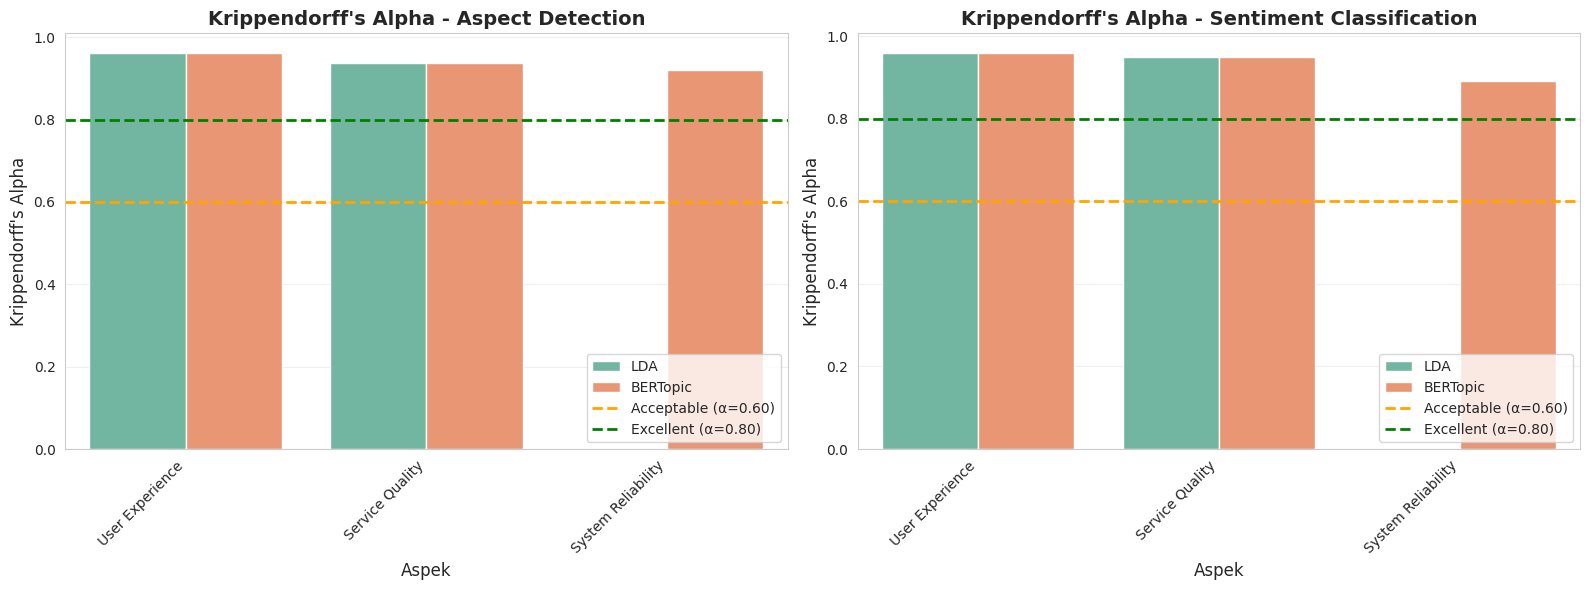

✅ Saved: /content/krippendorff_alpha_heatmap.png


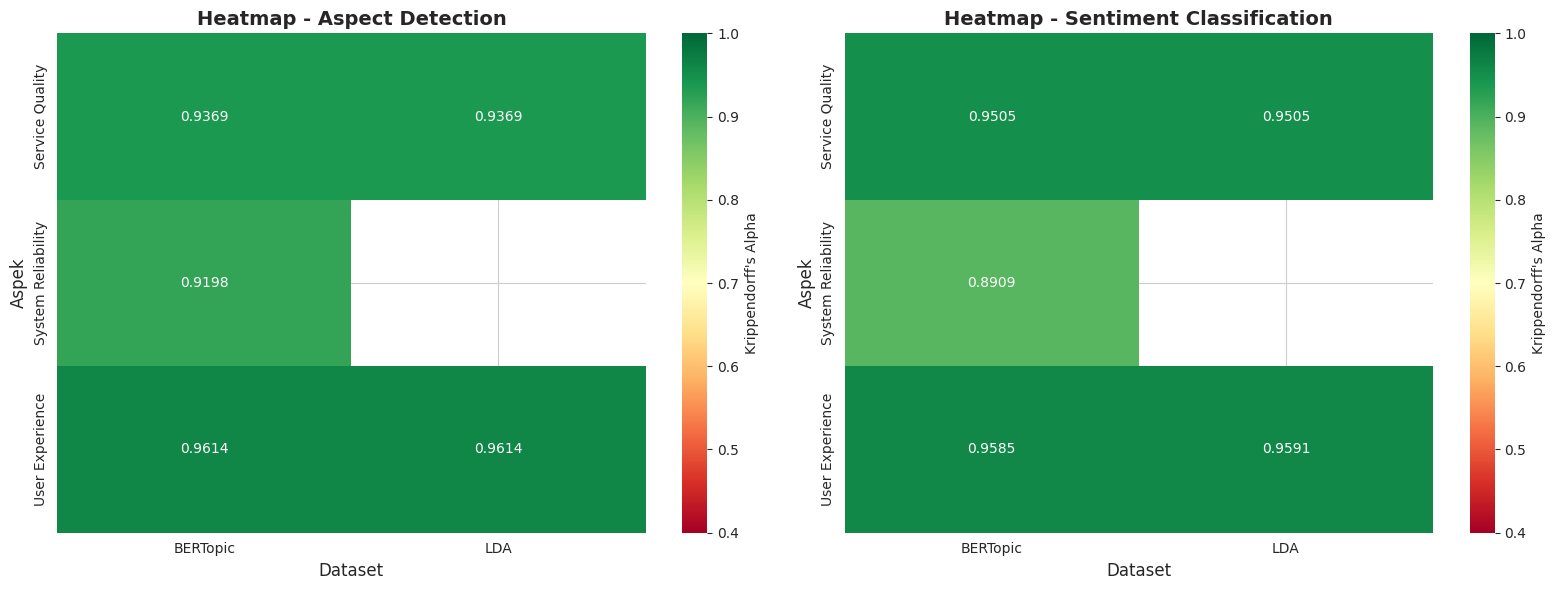


SELESAI! Semua perhitungan dan visualisasi telah dibuat.

File yang dibuat:
  1. /content/krippendorff_alpha_aspect_detection.csv
  2. /content/krippendorff_alpha_sentiment_classification.csv
  3. /content/krippendorff_alpha_complete.csv
  4. /content/krippendorff_alpha_comparison.png
  5. /content/krippendorff_alpha_heatmap.png


In [ ]:
print("\n" + "="*80)
print("STEP 9: VISUALISASI")
print("="*80 + "\n")

sns.set_style("whitegrid")

# ============================================================================
# 9.1: Bar Chart - Aspect Detection vs Sentiment Classification
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Aspect Detection
ax1 = axes[0]
df_aspek_plot = df_summary_aspek.copy()
sns.barplot(data=df_aspek_plot, x='Aspek', y='Alpha', hue='Dataset', palette='Set2', ax=ax1)
ax1.set_title("Krippendorff's Alpha - Aspect Detection", fontsize=14, fontweight='bold')
ax1.set_xlabel('Aspek', fontsize=12)
ax1.set_ylabel("Krippendorff's Alpha", fontsize=12)
ax1.axhline(y=0.60, color='orange', linestyle='--', label='Acceptable (α=0.60)', linewidth=2)
ax1.axhline(y=0.80, color='green', linestyle='--', label='Excellent (α=0.80)', linewidth=2)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.legend(loc='lower right')
ax1.grid(axis='y', alpha=0.3)

# Plot 2: Sentiment Classification
ax2 = axes[1]
df_sentimen_plot = df_summary_sentimen[~df_summary_sentimen['Alpha'].isna()].copy()
if len(df_sentimen_plot) > 0:
    sns.barplot(data=df_sentimen_plot, x='Aspek', y='Alpha', hue='Dataset', palette='Set2', ax=ax2)
    ax2.set_title("Krippendorff's Alpha - Sentiment Classification", fontsize=14, fontweight='bold')
    ax2.set_xlabel('Aspek', fontsize=12)
    ax2.set_ylabel("Krippendorff's Alpha", fontsize=12)
    ax2.axhline(y=0.60, color='orange', linestyle='--', label='Acceptable (α=0.60)', linewidth=2)
    ax2.axhline(y=0.80, color='green', linestyle='--', label='Excellent (α=0.80)', linewidth=2)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
    ax2.legend(loc='lower right')
    ax2.grid(axis='y', alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Tidak ada data valid\nuntuk Sentiment Classification',
             ha='center', va='center', fontsize=14, transform=ax2.transAxes)
    ax2.set_title("Krippendorff's Alpha - Sentiment Classification", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/krippendorff_alpha_comparison.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /content/krippendorff_alpha_comparison.png")
plt.show()

# ============================================================================
# 9.2: Heatmap
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: Aspect Detection
ax1 = axes[0]
pivot_aspek = df_summary_aspek.pivot(index='Aspek', columns='Dataset', values='Alpha')
sns.heatmap(pivot_aspek, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0.4, vmax=1.0,
            cbar_kws={'label': "Krippendorff's Alpha"}, ax=ax1)
ax1.set_title("Heatmap - Aspect Detection", fontsize=14, fontweight='bold')
ax1.set_xlabel('Dataset', fontsize=12)
ax1.set_ylabel('Aspek', fontsize=12)

# Heatmap 2: Sentiment Classification
ax2 = axes[1]
if len(df_sentimen_plot) > 0:
    pivot_sentimen = df_summary_sentimen[~df_summary_sentimen['Alpha'].isna()].pivot(
        index='Aspek', columns='Dataset', values='Alpha')
    sns.heatmap(pivot_sentimen, annot=True, fmt='.4f', cmap='RdYlGn', vmin=0.4, vmax=1.0,
                cbar_kws={'label': "Krippendorff's Alpha"}, ax=ax2)
    ax2.set_title("Heatmap - Sentiment Classification", fontsize=14, fontweight='bold')
    ax2.set_xlabel('Dataset', fontsize=12)
    ax2.set_ylabel('Aspek', fontsize=12)
else:
    ax2.text(0.5, 0.5, 'Tidak ada data valid', ha='center', va='center',
             fontsize=14, transform=ax2.transAxes)
    ax2.set_title("Heatmap - Sentiment Classification", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/krippendorff_alpha_heatmap.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /content/krippendorff_alpha_heatmap.png")
plt.show()

print("\n" + "="*80)
print("SELESAI! Semua perhitungan dan visualisasi telah dibuat.")
print("="*80)
print("\nFile yang dibuat:")
print("  1. /content/krippendorff_alpha_aspect_detection.csv")
print("  2. /content/krippendorff_alpha_sentiment_classification.csv")
print("  3. /content/krippendorff_alpha_complete.csv")
print("  4. /content/krippendorff_alpha_comparison.png")
print("  5. /content/krippendorff_alpha_heatmap.png")

# STEP 10: VISUALISASI DISTRIBUSI SENTIMEN PER ASPEK

# Distribusi Majority Voting


STEP 10: VISUALISASI DISTRIBUSI SENTIMEN PER ASPEK

10.1: LOAD DATA FINAL
--------------------------------------------------------------------------------

✅ LDA Final: 16220 ulasan
   Kolom: ['id', 'ulasan', 'final_text', 'User Experience', 'Service Quality']

✅ BERTopic Final: 16220 ulasan
   Kolom: ['id', 'ulasan', 'final_text', 'User Experience', 'Service Quality', 'System Reliability']

10.2: HITUNG DISTRIBUSI SENTIMEN
--------------------------------------------------------------------------------

Distribusi Sentimen - LDA:
--------------------------------------------------------------------------------
          Aspek  Tidak Ada (0)  Positif (1)  Negatif (2)  Total  Persen Positif  Persen Negatif  Persen Ada Aspek
User Experience           5279        10448          493  16220       64.414303        3.039457         67.453761
Service Quality          11957         4001          262  16220       24.667078        1.615290         26.282367
---------------------------------------

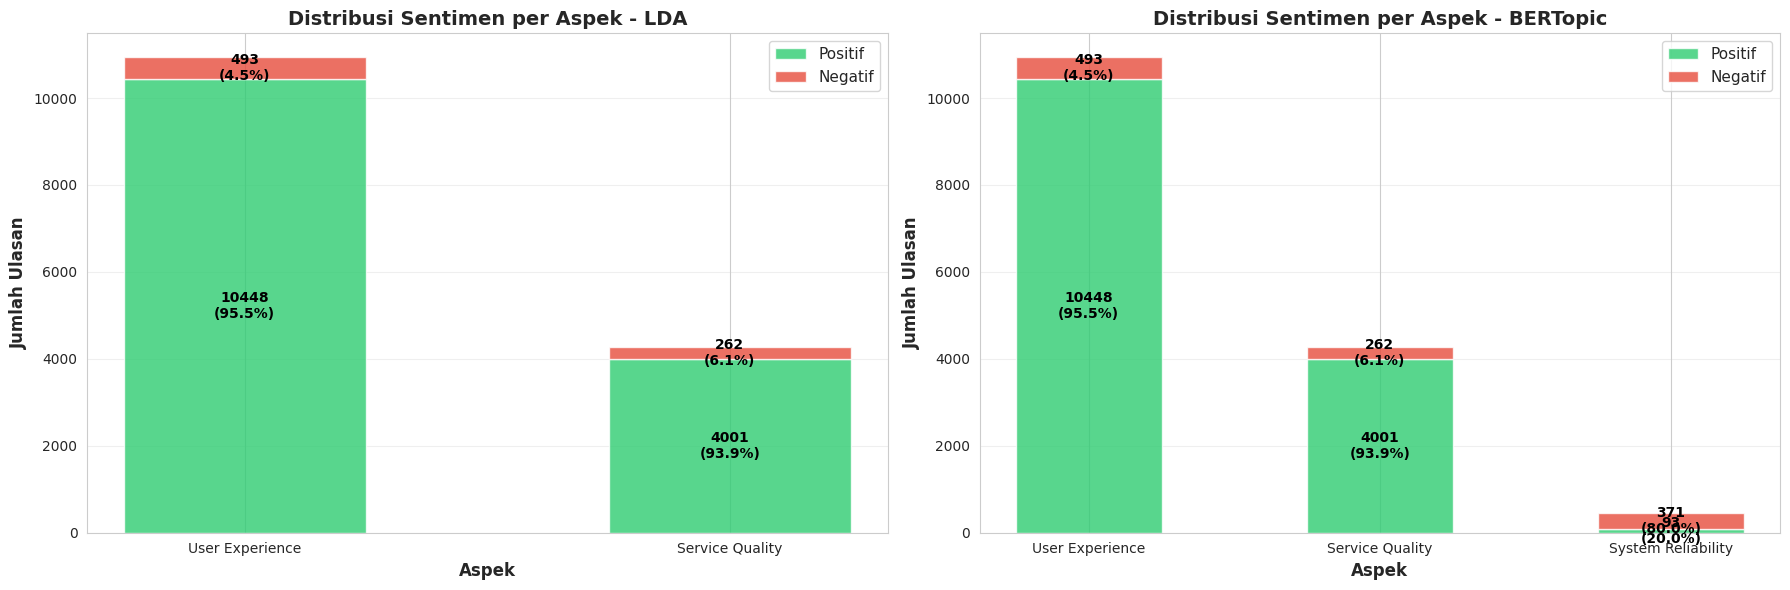


10.4: VISUALISASI BAR CHART - GROUPED (SIDE-BY-SIDE)
--------------------------------------------------------------------------------

✅ Saved: /content/distribusi_sentimen_grouped_bar.png


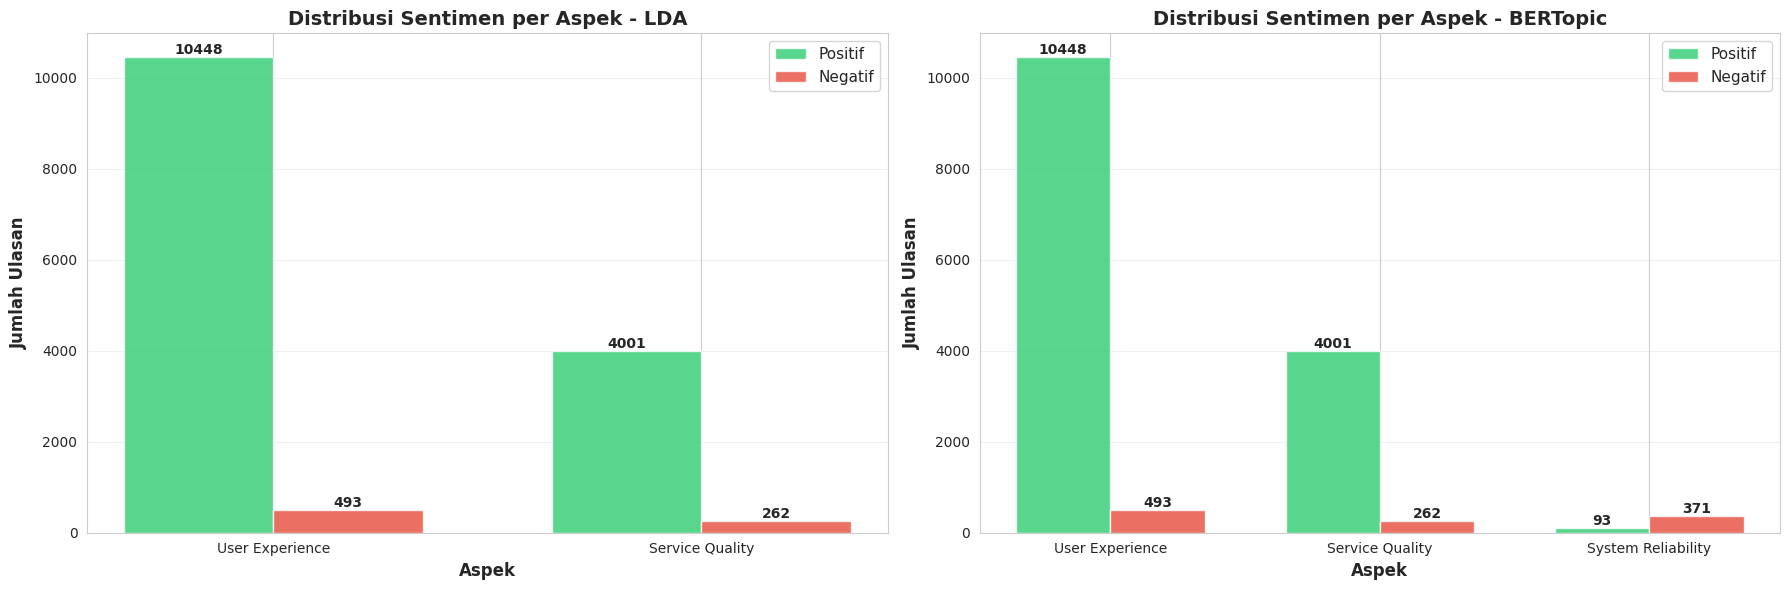


10.5: PIE CHART - PROPORSI SENTIMEN
--------------------------------------------------------------------------------

✅ Saved: /content/distribusi_sentimen_pie_lda.png


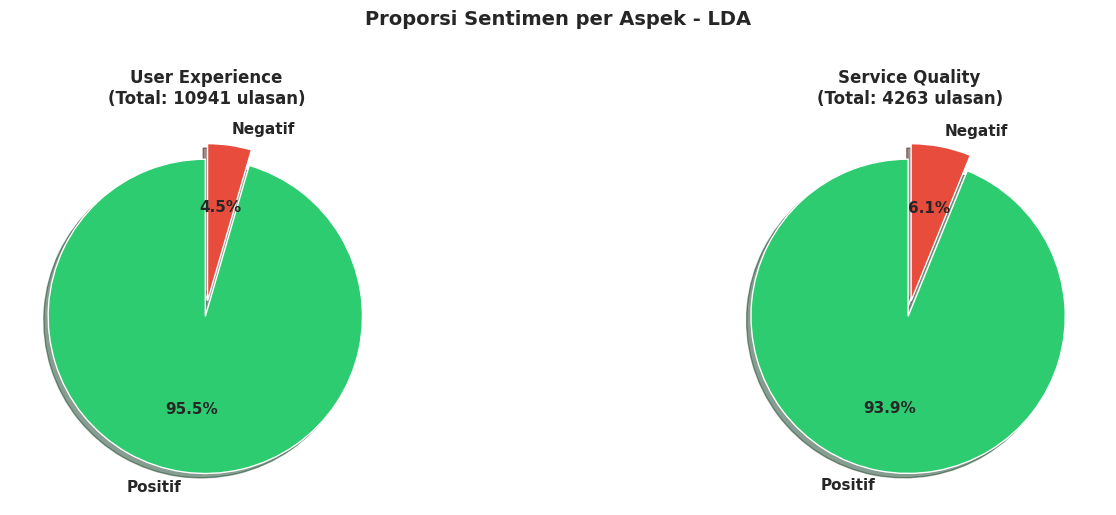

✅ Saved: /content/distribusi_sentimen_pie_bertopic.png


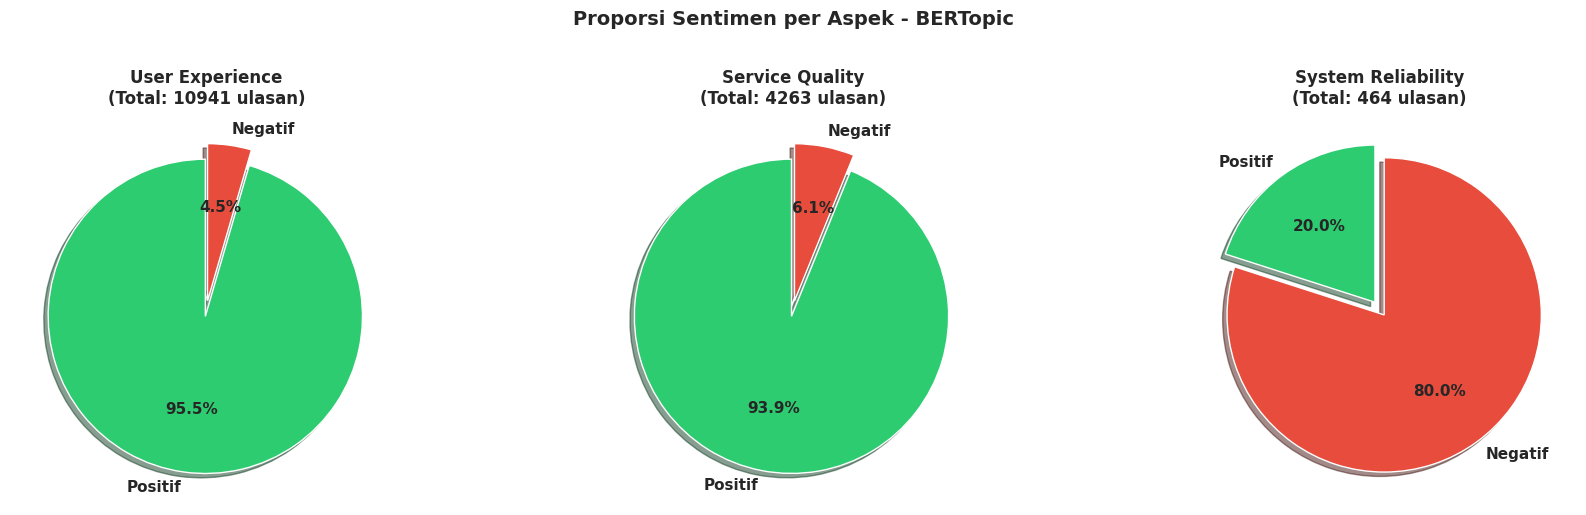


✅ VISUALISASI DISTRIBUSI SENTIMEN SELESAI!

File yang dibuat:
  1. /content/distribusi_sentimen_lda.csv
  2. /content/distribusi_sentimen_bertopic.csv
  3. /content/distribusi_sentimen_stacked_bar.png
  4. /content/distribusi_sentimen_grouped_bar.png
  5. /content/distribusi_sentimen_pie_lda.png
  6. /content/distribusi_sentimen_pie_bertopic.png


In [ ]:
print("\n" + "="*80)
print("STEP 10: VISUALISASI DISTRIBUSI SENTIMEN PER ASPEK")
print("="*80 + "\n")

# ============================================================================
# 10.1: LOAD DATA FINAL (DENGAN LABEL AKHIR)
# ============================================================================

print("10.1: LOAD DATA FINAL")
print("-"*80 + "\n")

path_lda_final = "/content/drive/MyDrive/SKRIPSI/DATASET/ulasan_plnmobile_labeling_LDA_final.csv"
path_ber_final = "/content/drive/MyDrive/SKRIPSI/DATASET/ulasan_plnmobile_labeling_BERTopic_final.csv"

df_lda_final = pd.read_csv(path_lda_final, sep=';', encoding='utf-8', engine='python')
df_ber_final = pd.read_csv(path_ber_final, sep=';', encoding='utf-8', engine='python')

print(f"✅ LDA Final: {len(df_lda_final)} ulasan")
print(f"   Kolom: {df_lda_final.columns.tolist()}")
print(f"\n✅ BERTopic Final: {len(df_ber_final)} ulasan")
print(f"   Kolom: {df_ber_final.columns.tolist()}")

# ============================================================================
# 10.2: HITUNG DISTRIBUSI SENTIMEN
# ============================================================================

print("\n10.2: HITUNG DISTRIBUSI SENTIMEN")
print("-"*80 + "\n")

def count_sentiment_distribution(df, aspects):
    """
    Hitung distribusi sentimen untuk setiap aspek

    Returns: DataFrame dengan kolom [Aspek, Tidak Ada (0), Positif (1), Negatif (2)]
    """
    distribution = []

    for aspect in aspects:
        # PERBAIKAN: Gunakan nama kolom ASLI (dengan spasi, bukan underscore)
        if aspect in df.columns:
            # Hitung distribusi
            counts = df[aspect].value_counts().sort_index()

            # Pastikan semua kategori ada (0, 1, 2)
            count_0 = counts.get(0, 0)  # Tidak ada aspek
            count_1 = counts.get(1, 0)  # Positif
            count_2 = counts.get(2, 0)  # Negatif

            total = count_0 + count_1 + count_2

            distribution.append({
                'Aspek': aspect,
                'Tidak Ada (0)': count_0,
                'Positif (1)': count_1,
                'Negatif (2)': count_2,
                'Total': total,
                'Persen Positif': (count_1 / total * 100) if total > 0 else 0,
                'Persen Negatif': (count_2 / total * 100) if total > 0 else 0,
                'Persen Ada Aspek': ((count_1 + count_2) / total * 100) if total > 0 else 0
            })
        else:
            print(f"⚠️ Kolom '{aspect}' tidak ditemukan!")

    return pd.DataFrame(distribution)

# LDA - GUNAKAN NAMA DENGAN SPASI
aspects_lda = ['User Experience', 'Service Quality']
dist_lda = count_sentiment_distribution(df_lda_final, aspects_lda)

print("Distribusi Sentimen - LDA:")
print("-"*80)
print(dist_lda.to_string(index=False))
print("-"*80)

# BERTopic - GUNAKAN NAMA DENGAN SPASI
aspects_ber = ['User Experience', 'Service Quality', 'System Reliability']
dist_ber = count_sentiment_distribution(df_ber_final, aspects_ber)

print("\nDistribusi Sentimen - BERTopic:")
print("-"*80)
print(dist_ber.to_string(index=False))
print("-"*80)

# Simpan CSV
dist_lda.to_csv('/content/distribusi_sentimen_lda.csv', index=False)
dist_ber.to_csv('/content/distribusi_sentimen_bertopic.csv', index=False)
print("\n✅ Saved: /content/distribusi_sentimen_lda.csv")
print("✅ Saved: /content/distribusi_sentimen_bertopic.csv")

# ============================================================================
# 10.3: VISUALISASI BAR CHART - STACKED
# ============================================================================

print("\n10.3: VISUALISASI BAR CHART - STACKED")
print("-"*80 + "\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ============================================================================
# Plot 1: LDA - Stacked Bar Chart
# ============================================================================

ax1 = axes[0]

# Data untuk plotting
x_lda = np.arange(len(dist_lda))
width = 0.5

# Hitung persentase
total_lda = dist_lda['Positif (1)'].values + dist_lda['Negatif (2)'].values
pct_pos_lda = (dist_lda['Positif (1)'].values / total_lda * 100)
pct_neg_lda = (dist_lda['Negatif (2)'].values / total_lda * 100)

# Stacked bars
bars1 = ax1.bar(x_lda, dist_lda['Positif (1)'], width,
                label='Positif', color='#2ecc71', alpha=0.8)
bars2 = ax1.bar(x_lda, dist_lda['Negatif (2)'], width,
                bottom=dist_lda['Positif (1)'],
                label='Negatif', color='#e74c3c', alpha=0.8)

# Tambahkan nilai di atas bar
for i, (pos, neg) in enumerate(zip(dist_lda['Positif (1)'], dist_lda['Negatif (2)'])):
    # Label positif
    if pos > 0:
        ax1.text(i, pos/2, f'{int(pos)}\n({pct_pos_lda[i]:.1f}%)',
                 ha='center', va='center', fontsize=10, fontweight='bold', color='black')
    # Label negatif
    if neg > 0:
        ax1.text(i, pos + neg/2, f'{int(neg)}\n({pct_neg_lda[i]:.1f}%)',
                 ha='center', va='center', fontsize=10, fontweight='bold', color='black')

ax1.set_xlabel('Aspek', fontsize=12, fontweight='bold')
ax1.set_ylabel('Jumlah Ulasan', fontsize=12, fontweight='bold')
ax1.set_title('Distribusi Sentimen per Aspek - LDA', fontsize=14, fontweight='bold')
ax1.set_xticks(x_lda)
ax1.set_xticklabels(dist_lda['Aspek'], rotation=0)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# ============================================================================
# Plot 2: BERTopic - Stacked Bar Chart
# ============================================================================

ax2 = axes[1]

x_ber = np.arange(len(dist_ber))

# Hitung persentase
total_ber = dist_ber['Positif (1)'].values + dist_ber['Negatif (2)'].values
pct_pos_ber = (dist_ber['Positif (1)'].values / total_ber * 100)
pct_neg_ber = (dist_ber['Negatif (2)'].values / total_ber * 100)

# Stacked bars
bars3 = ax2.bar(x_ber, dist_ber['Positif (1)'], width,
                label='Positif', color='#2ecc71', alpha=0.8)
bars4 = ax2.bar(x_ber, dist_ber['Negatif (2)'], width,
                bottom=dist_ber['Positif (1)'],
                label='Negatif', color='#e74c3c', alpha=0.8)

# Tambahkan nilai di atas bar
for i, (pos, neg) in enumerate(zip(dist_ber['Positif (1)'], dist_ber['Negatif (2)'])):
    if pos > 0:
        ax2.text(i, pos/2, f'{int(pos)}\n({pct_pos_ber[i]:.1f}%)',
                 ha='center', va='center', fontsize=10, fontweight='bold', color='black')
    if neg > 0:
        ax2.text(i, pos + neg/2, f'{int(neg)}\n({pct_neg_ber[i]:.1f}%)',
                 ha='center', va='center', fontsize=10, fontweight='bold', color='black')

ax2.set_xlabel('Aspek', fontsize=12, fontweight='bold')
ax2.set_ylabel('Jumlah Ulasan', fontsize=12, fontweight='bold')
ax2.set_title('Distribusi Sentimen per Aspek - BERTopic', fontsize=14, fontweight='bold')
ax2.set_xticks(x_ber)
ax2.set_xticklabels(dist_ber['Aspek'], rotation=0)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/distribusi_sentimen_stacked_bar.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /content/distribusi_sentimen_stacked_bar.png")
plt.show()

# ============================================================================
# 10.4: VISUALISASI BAR CHART - GROUPED (SIDE-BY-SIDE)
# ============================================================================

print("\n10.4: VISUALISASI BAR CHART - GROUPED (SIDE-BY-SIDE)")
print("-"*80 + "\n")

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: LDA
ax1 = axes[0]

x_lda = np.arange(len(dist_lda))
width = 0.35

bars1 = ax1.bar(x_lda - width/2, dist_lda['Positif (1)'], width,
                label='Positif', color='#2ecc71', alpha=0.8)
bars2 = ax1.bar(x_lda + width/2, dist_lda['Negatif (2)'], width,
                label='Negatif', color='#e74c3c', alpha=0.8)

# Tambahkan nilai di atas bar
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

ax1.set_xlabel('Aspek', fontsize=12, fontweight='bold')
ax1.set_ylabel('Jumlah Ulasan', fontsize=12, fontweight='bold')
ax1.set_title('Distribusi Sentimen per Aspek - LDA', fontsize=14, fontweight='bold')
ax1.set_xticks(x_lda)
ax1.set_xticklabels(dist_lda['Aspek'], rotation=0)
ax1.legend(loc='upper right', fontsize=11)
ax1.grid(axis='y', alpha=0.3)

# Plot 2: BERTopic
ax2 = axes[1]

x_ber = np.arange(len(dist_ber))

bars3 = ax2.bar(x_ber - width/2, dist_ber['Positif (1)'], width,
                label='Positif', color='#2ecc71', alpha=0.8)
bars4 = ax2.bar(x_ber + width/2, dist_ber['Negatif (2)'], width,
                label='Negatif', color='#e74c3c', alpha=0.8)

for bars in [bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}',
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

ax2.set_xlabel('Aspek', fontsize=12, fontweight='bold')
ax2.set_ylabel('Jumlah Ulasan', fontsize=12, fontweight='bold')
ax2.set_title('Distribusi Sentimen per Aspek - BERTopic', fontsize=14, fontweight='bold')
ax2.set_xticks(x_ber)
ax2.set_xticklabels(dist_ber['Aspek'], rotation=0)
ax2.legend(loc='upper right', fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/distribusi_sentimen_grouped_bar.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /content/distribusi_sentimen_grouped_bar.png")
plt.show()

# ============================================================================
# 10.5: PIE CHART - PROPORSI SENTIMEN
# ============================================================================

print("\n10.5: PIE CHART - PROPORSI SENTIMEN")
print("-"*80 + "\n")

# LDA
fig, axes = plt.subplots(1, len(dist_lda), figsize=(16, 5))

for i, (idx, row) in enumerate(dist_lda.iterrows()):
    ax = axes[i] if len(dist_lda) > 1 else axes

    sizes = [row['Positif (1)'], row['Negatif (2)']]
    labels = ['Positif', 'Negatif']
    colors = ['#2ecc71', '#e74c3c']
    explode = (0.05, 0.05)

    ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
           shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax.set_title(f"{row['Aspek']}\n(Total: {int(row['Positif (1)'] + row['Negatif (2)'])} ulasan)",
                 fontsize=12, fontweight='bold')

plt.suptitle('Proporsi Sentimen per Aspek - LDA', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/distribusi_sentimen_pie_lda.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /content/distribusi_sentimen_pie_lda.png")
plt.show()

# BERTopic
fig, axes = plt.subplots(1, len(dist_ber), figsize=(18, 5))

for i, (idx, row) in enumerate(dist_ber.iterrows()):
    ax = axes[i]

    sizes = [row['Positif (1)'], row['Negatif (2)']]
    labels = ['Positif', 'Negatif']
    colors = ['#2ecc71', '#e74c3c']
    explode = (0.05, 0.05)

    ax.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
           shadow=True, startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'})
    ax.set_title(f"{row['Aspek']}\n(Total: {int(row['Positif (1)'] + row['Negatif (2)'])} ulasan)",
                 fontsize=12, fontweight='bold')

plt.suptitle('Proporsi Sentimen per Aspek - BERTopic', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/distribusi_sentimen_pie_bertopic.png', dpi=300, bbox_inches='tight')
print("✅ Saved: /content/distribusi_sentimen_pie_bertopic.png")
plt.show()

print("\n" + "="*80)
print("✅ VISUALISASI DISTRIBUSI SENTIMEN SELESAI!")
print("="*80)
print("\nFile yang dibuat:")
print("  1. /content/distribusi_sentimen_lda.csv")
print("  2. /content/distribusi_sentimen_bertopic.csv")
print("  3. /content/distribusi_sentimen_stacked_bar.png")
print("  4. /content/distribusi_sentimen_grouped_bar.png")
print("  5. /content/distribusi_sentimen_pie_lda.png")
print("  6. /content/distribusi_sentimen_pie_bertopic.png")